In [132]:
import os
import numpy as np
import cv2
import pandas as pd
import warnings
import matplotlib.pyplot as plt

In [133]:
##base path -- /home/zaid/Desktop/manas/Manas/NeuralNetwork/Train

In [134]:
data = []
base_path = "/home/zaid/Desktop/manas/Manas/NeuralNetwork/Train"
classes = os.listdir(base_path)
classes

['James', 'Joel', 'Jovi', 'Jane', 'Jade']

In [135]:
data = []
names = []
counter = 0
for i in classes:
    class_path = f"/home/zaid/Desktop/manas/Manas/NeuralNetwork/Train/{i}"
    for j in os.listdir(class_path):
        img_path = f"/home/zaid/Desktop/manas/Manas/NeuralNetwork/Train/{i}/{j}"
        img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
        if img is not None:
            data.append(img.flatten())
            names.append([counter,i,j])
            counter += 1
        else:
            print("Image not found!")
            continue

Image not found!


In [136]:
data = np.array(data)
names = pd.DataFrame(names)

In [137]:
names # james,joel,jovi,jane,jade
names = names[:][1].map({"James":0, "Joel": 1, "Jovi": 2, "Jane": 3, "Jade": 4})

In [138]:
names

0       0
1       0
2       0
3       0
4       0
       ..
3995    4
3996    4
3997    4
3998    4
3999    4
Name: 1, Length: 4000, dtype: int64

In [139]:
data = data.T  ## 748,4000

In [140]:
def get_weight(number_neurons, number_inputs):
    return np.random.randn(number_neurons, number_inputs) * 0.01

def get_biases(number_neurons):
    # return np.zeros((number_neurons, 1))
    return 0
    
def pred(inputs, weights, biases):
    return np.dot(weights, inputs) + biases

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(inputs):
    return np.maximum(0, inputs)

def softmax(inputs):
    exp_values = np.exp(inputs - np.max(inputs, axis=0, keepdims=True)) 
    return exp_values / np.sum(exp_values, axis=0, keepdims=True)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def loss_fn(Y, Y_pred):
    Y_pred_clipped = np.clip(Y_pred, 1e-10, 1 - 1e-10)
    return -np.mean(np.sum(Y * np.log(Y_pred_clipped + 1e-10), axis=0))

def accuracy(true_classes, predicted_classes):
    return np.mean(true_classes == predicted_classes) * 100


In [141]:
## min-max scaling
data = data/255
data.shape

(784, 4000)

In [142]:
weights_h1 = get_weight(200,784)
biases_h1 = get_biases(200)
# neurons_h1 = pd.DataFrame(neurons_h1)

weights_h2 = get_weight(10,200)
biases_h2 = get_biases(10)
# neurons_h2 = pd.DataFrame(neurons_h2)

weights_h3 = get_weight(5,10)
biases_h3 = get_biases(5)
# neurons_h3 = pd.DataFrame(neurons_h3)
warnings.filterwarnings("ignore", category=FutureWarning)

In [143]:
one_hot = pd.get_dummies(names,columns = [0]).astype(float)
one_hot = one_hot.T

In [144]:
lr = 0.1
epochs = 1000
loss_history = []
for _ in range(epochs):
    neurons_h1 = pred(data,weights_h1,biases_h1)
    # neurons_h1 = pd.DataFrame(neurons_h1)
    a_neurons_h1 = relu(neurons_h1)
    
    neurons_h2 = pred(a_neurons_h1,weights_h2,biases_h2)
    # neurons_h2 = pd.DataFrame(neurons_h2)
    a_neurons_h2 = relu(neurons_h2) 
    
    neurons_h3 = pred(a_neurons_h2,weights_h3,biases_h3)
    # neurons_h3 = pd.DataFrame(neurons_h3)
    a_neurons_h3 = softmax(neurons_h3)
    
    loss = loss_fn(one_hot, a_neurons_h3)
    loss_history.append(loss)

    dz3 = a_neurons_h3-one_hot  ## 5,4000
    dw3 = (1/4000)*np.dot(dz3,(a_neurons_h2.T))
    db3 = (1/4000)*np.sum(np.sum(dz3))
    dz2 = np.dot(weights_h3.T,dz3) * relu_derivative(a_neurons_h2)

    dw2 = (1/4000) * np.dot(dz2,(a_neurons_h1.T))
    db2 = (1/4000) * np.sum(dz2)
    dz1 = np.dot(weights_h2.T,dz2) * relu_derivative(a_neurons_h1)

    dw1 = (1/4000) * np.dot(dz1,data.T)
    db1 = (1/4000) * np.sum(dz1)
    
    if (_+1) % 100 == 0:
        print(loss)
    weights_h3 -= lr * dw3
    weights_h2 -= lr * dw2
    weights_h1 -= lr * dw1
    biases_h3 -= lr * db3
    biases_h2 -= lr * db2
    biases_h1 -= lr * db1
    warnings.filterwarnings("ignore", category=FutureWarning)

1.6092923032153243
1.607958905054727
1.4764396319833877
1.1229931341630013
0.6204457504573505
0.3470873276074266
0.255373587331786
0.18525808444475453
0.408202308540308
0.10922492842570142


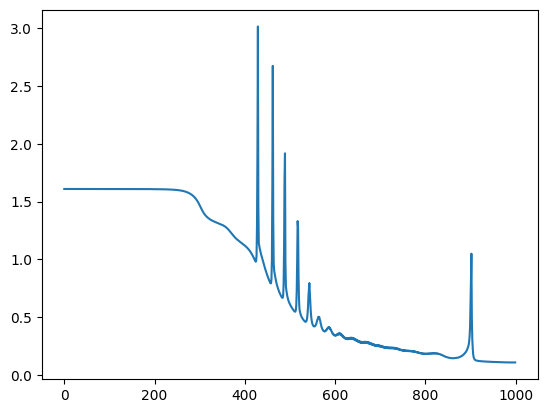

In [145]:
plt.plot(loss_history)
plt.savefig("loss graph")
plt.show()

In [146]:
min(loss_history)

np.float64(0.10887983726886813)

In [147]:
predicted_classes = np.argmax(a_neurons_h3, axis=0)
true_classes = np.argmax(one_hot, axis=0)
acc = accuracy(true_classes.T, predicted_classes.T)
print(f"Training Accuracy: {acc:.2f}%")

Training Accuracy: 96.00%


In [152]:
import csv

In [153]:
df1 = pd.DataFrame(weights_h1)
df1.to_csv("w1.csv", index=True)

df2 = pd.DataFrame(weights_h2)
df2.to_csv("w2.csv", index=True)

df3 = pd.DataFrame(weights_h3)
df3.to_csv("w3.csv", index=True)

In [154]:

df4 = pd.DataFrame([biases_h1,biases_h2,biases_h3])
df4.to_csv("b.csv", index=True)
